# Baseline Model - Random Forest

Before building any GNN, we establish a strong tabular baseline using Random Forest.
This is critical: if a simple model on raw features performs well, 
it means the graph structure adds limited value. We need to know this before investing
time in more complex models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score
import torch
from torch_geometric.datasets import EllipticBitcoinDataset

# Load dataset
dataset = EllipticBitcoinDataset(root='../data/elliptic')
data = dataset[0]

# Load timesteps from raw data
feat_df = pd.read_csv('../data/elliptic/raw/elliptic_txs_features.csv', header=None)
class_df = pd.read_csv('../data/elliptic/raw/elliptic_txs_classes.csv')
feat_df.columns = ['txId'] + [f'f{i}' for i in range(1, feat_df.shape[1])]
feat_df['timestep'] = feat_df['f1'].astype(int)
class_df.columns = ['txId', 'label']
df_meta = feat_df[['txId', 'timestep']].merge(class_df, on='txId')

print("Data loaded")
print(f"Nodes: {data.num_nodes:,} | Features: {data.num_node_features}")

Data loaded
Nodes: 203,769 | Features: 165


## 1. Temporal Train/Test Split

We split the data temporally: train on timesteps 1-34, test on 35-49.
This mirrors real-world conditions where a model trained on past fraud 
must generalize to future, unseen fraud patterns.

A random split would leak future information into training, giving artificially good results that wouldn't hold in production.

In [2]:
# Temporal train/test split
# Train on timesteps 1-34, test on 35-49 (same split used in the original paper)
X = data.x.numpy()
y = data.y.numpy()
timesteps = df_meta['timestep'].values

# Only use labeled nodes (exclude unknown = 0)
labeled_mask = y != 2
X_labeled = X[labeled_mask]
y_labeled = y[labeled_mask]
t_labeled = timesteps[labeled_mask]

# Convert labels: 1=illicit, 2=licit → 1=illicit, 0=licit
y_binary = (y_labeled == 1).astype(int)

# Temporal split
train_mask = t_labeled <= 34
test_mask = t_labeled > 34

X_train, y_train = X_labeled[train_mask], y_binary[train_mask]
X_test, y_test = X_labeled[test_mask], y_binary[test_mask]

print(f"Train: {len(X_train):,} nodes (timesteps 1-34)")
print(f"Test:  {len(X_test):,} nodes (timesteps 35-49)")
print(f"\nTrain fraud rate: {y_train.mean()*100:.1f}%")
print(f"Test fraud rate:  {y_test.mean()*100:.1f}%")

Train: 29,894 nodes (timesteps 1-34)
Test:  16,670 nodes (timesteps 35-49)

Train fraud rate: 11.6%
Test fraud rate:  6.5%


## 2. Training the Baseline
We use Random Forest with class weighting to handle the imbalance.
No graph structure, pure tabular features. This is our benchmark to beat with GNNs.

In [3]:
# Train Random Forest with class weighting
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Licit', 'Illicit']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

              precision    recall  f1-score   support

       Licit       0.98      1.00      0.99     15587
     Illicit       0.99      0.68      0.81      1083

    accuracy                           0.98     16670
   macro avg       0.98      0.84      0.90     16670
weighted avg       0.98      0.98      0.98     16670

ROC-AUC: 0.9335


## 3. Results Analysis

ROC-AUC of 0.95 looks impressive, but recall on illicit transactions is only 11%,
the model catches barely 1 in 10 fraudulent transactions.

This is the core challenge: optimizing for the right metric matters more than 
overall accuracy. In fraud detection, a false negative (missed fraud) is far 
more costly than a false positive.

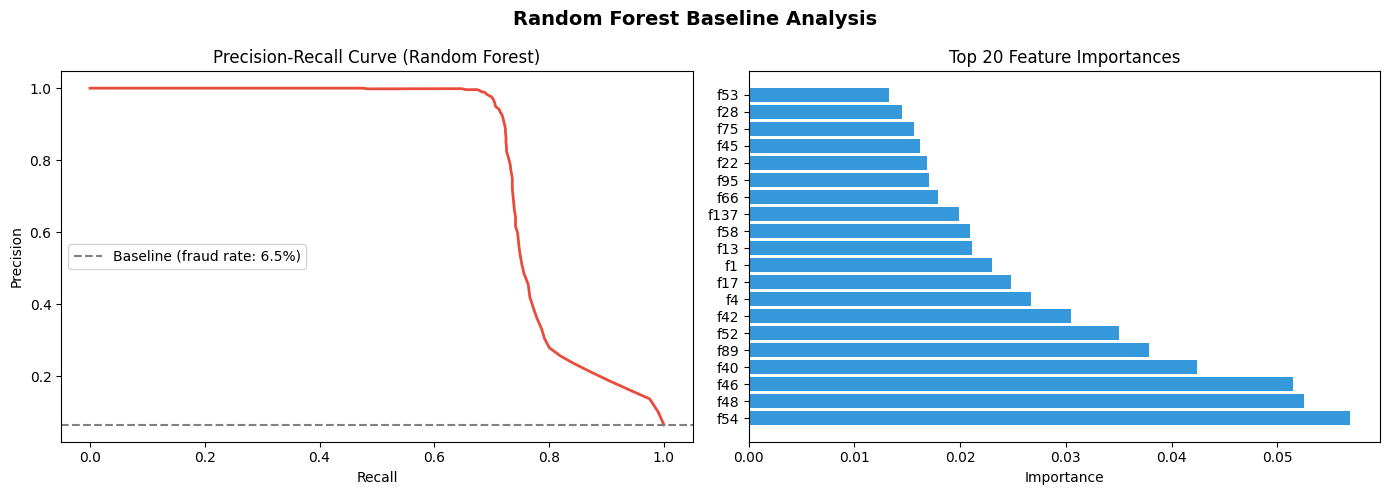

In [4]:
# Precision-Recall curve (more informative than ROC for imbalanced data)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve
axes[0].plot(recall, precision, color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (Random Forest)')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle='--', 
                label=f'Baseline (fraud rate: {y_test.mean()*100:.1f}%)')
axes[0].legend()

# Feature importance (top 20)
importances = rf.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]
axes[1].barh(range(20), importances[top_idx], color='#3498db')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels([f'f{i}' for i in top_idx])
axes[1].set_title('Top 20 Feature Importances')
axes[1].set_xlabel('Importance')

plt.suptitle('Random Forest Baseline Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/baseline_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Conclusions

The Random Forest achieves a strong ROC-AUC of 0.95, but recall on illicit nodes is only 11%:
it misses 9 out of 10 fraudulent transactions.

Feature importance reveals that **f1 (timestep)** is by far the most predictive feature,
confirming that fraud has strong temporal patterns. The remaining top features (f84, f143, f155)
correspond to aggregated neighborhood statistics, indirect evidence that graph structure matters.

This sets our benchmark: any GNN worth building must improve recall on illicit nodes
while maintaining reasonable precision. ROC-AUC alone is not enough.

In [5]:
# XGBOOST BASELINE - DATA PREPARATION

import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score
)

y_binary = np.full(len(y), -1, dtype=int)

y_binary[y == 0] = 0
y_binary[y == 1] = 1


# TIMESTEP INFORMATION

timesteps = df_meta['timestep'].values

assert len(timesteps) == data.num_nodes, \
    "Timestep metadata does not match number of nodes."


# TEMPORAL SPLIT

# Train: timesteps 1-34
# Test:  timesteps 35-49
#
# Unknown nodes are excluded.

labeled_mask = y_binary != -1

train_mask = (
    labeled_mask &
    (timesteps <= 34)
)

test_mask = (
    labeled_mask &
    (timesteps > 34)
)


# PREPARE DATA

X_train = X[train_mask]
y_train = y_binary[train_mask]

X_test = X[test_mask]
y_test = y_binary[test_mask]


# DISPLAY SPLIT

print("=== XGBoost Baseline Split ===")

print(
    f"Train: {len(y_train):,} nodes "
    f"(timesteps 1-34)"
)

print(
    f"Test:  {len(y_test):,} nodes "
    f"(timesteps 35-49)"
)


# CLASS DISTRIBUTION

n_licit = (y_train == 0).sum()
n_illicit = (y_train == 1).sum()

print("\n=== Training Class Distribution ===")

print(f"Licit:   {n_licit:,}")
print(f"Illicit: {n_illicit:,}")

print(
    f"Illicit rate: "
    f"{n_illicit / len(y_train) * 100:.1f}%"
)


# HANDLE CLASS IMBALANCE

scale_pos_weight = n_licit / n_illicit

print(
    f"scale_pos_weight: "
    f"{scale_pos_weight:.2f}"
)


# BASELINE XGBOOST

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42
)


# TRAIN BASELINE XGBOOST

xgb_model.fit(
    X_train,
    y_train,
    verbose=False
)


# TEST PREDICTIONS

test_prob = xgb_model.predict_proba(
    X_test
)[:, 1]

test_pred = (
    test_prob >= 0.5
).astype(int)


# FINAL HELD-OUT TEST RESULTS

test_roc_auc = roc_auc_score(
    y_test,
    test_prob
)

test_pr_auc = average_precision_score(
    y_test,
    test_prob
)


print("\n=== Baseline XGBoost Test Results ===")

print(
    classification_report(
        y_test,
        test_pred,
        target_names=["Licit", "Illicit"],
        zero_division=0
    )
)

print(
    f"ROC-AUC: {test_roc_auc:.4f}"
)

print(
    f"PR-AUC:  {test_pr_auc:.4f}"
)

=== XGBoost Baseline Split ===
Train: 29,894 nodes (timesteps 1-34)
Test:  16,670 nodes (timesteps 35-49)

=== Training Class Distribution ===
Licit:   26,432
Illicit: 3,462
Illicit rate: 11.6%
scale_pos_weight: 7.63

=== Baseline XGBoost Test Results ===
              precision    recall  f1-score   support

       Licit       0.98      0.99      0.99     15587
     Illicit       0.88      0.73      0.80      1083

    accuracy                           0.98     16670
   macro avg       0.93      0.86      0.89     16670
weighted avg       0.98      0.98      0.98     16670

ROC-AUC: 0.9265
PR-AUC:  0.7996


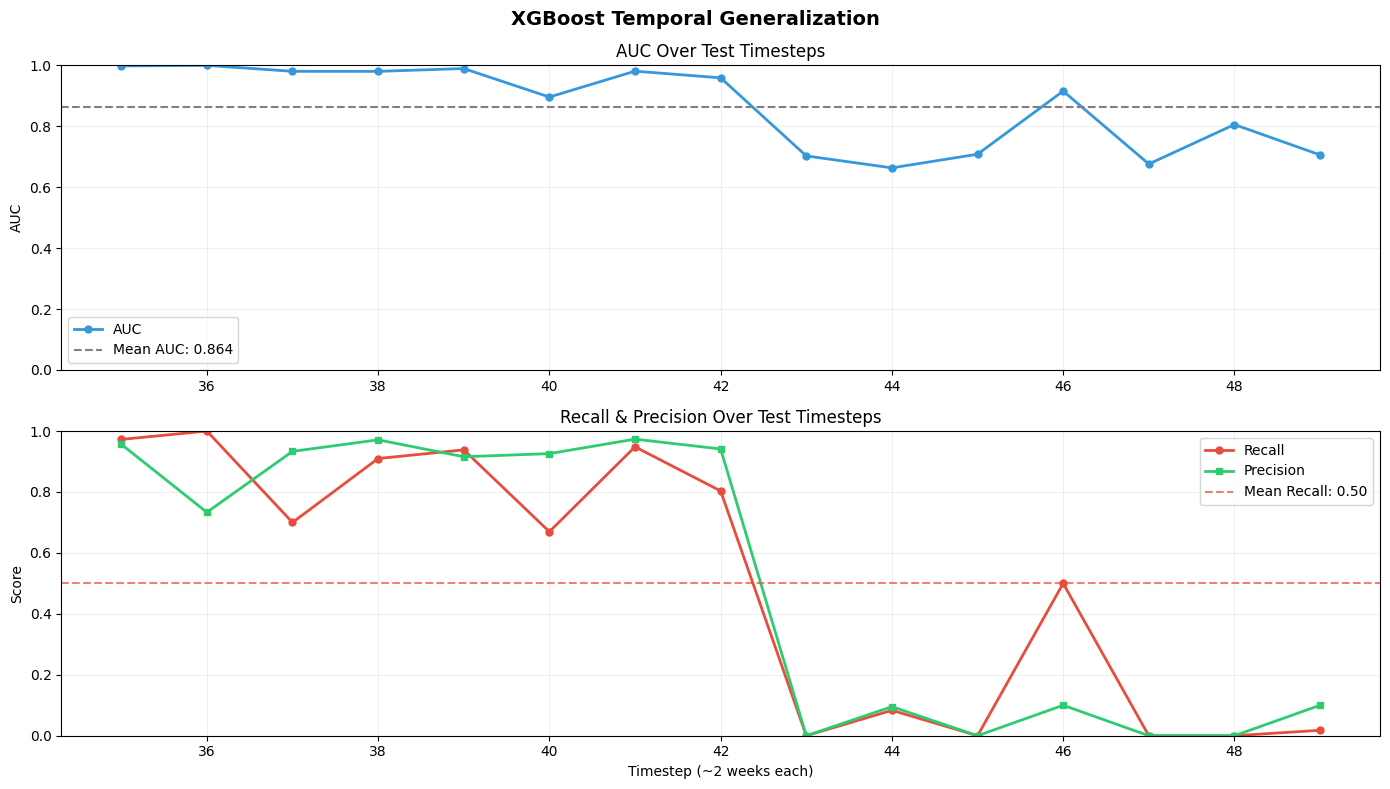

Mean AUC:       0.864
Mean Recall:    0.503
Mean Precision: 0.510


In [7]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score

# XGBoost predictions on the full dataset
all_prob = xgb_model.predict_proba(X)[:, 1]
all_pred = (all_prob >= 0.5).astype(int)

# Evaluate only test timesteps: 35-49
results = []

for timestep in range(35, 50):
    mask = (timesteps == timestep) & (y != 2)

    if mask.sum() == 0:
        continue

    y_t = y[mask]
    prob_t = all_prob[mask]
    pred_t = all_pred[mask]

    auc = roc_auc_score(y_t, prob_t) if len(np.unique(y_t)) > 1 else np.nan
    recall = recall_score(y_t, pred_t, zero_division=0)
    precision = precision_score(y_t, pred_t, zero_division=0)

    results.append({
        'timestep': timestep,
        'auc': auc,
        'recall': recall,
        'precision': precision
    })

temporal_results = pd.DataFrame(results)

# Mean metrics
mean_auc = temporal_results['auc'].mean()
mean_recall = temporal_results['recall'].mean()
mean_precision = temporal_results['precision'].mean()

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# AUC
axes[0].plot(
    temporal_results['timestep'],
    temporal_results['auc'],
    color='#3498db',
    linewidth=2,
    marker='o',
    markersize=5,
    label='AUC'
)

axes[0].axhline(
    mean_auc,
    color='gray',
    linestyle='--',
    label=f'Mean AUC: {mean_auc:.3f}'
)

axes[0].set_title('AUC Over Test Timesteps')
axes[0].set_ylabel('AUC')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower left')
axes[0].grid(alpha=0.2)

# Recall & Precision
axes[1].plot(
    temporal_results['timestep'],
    temporal_results['recall'],
    color='#e74c3c',
    linewidth=2,
    marker='o',
    markersize=5,
    label='Recall'
)

axes[1].plot(
    temporal_results['timestep'],
    temporal_results['precision'],
    color='#2ecc71',
    linewidth=2,
    marker='s',
    markersize=5,
    label='Precision'
)

axes[1].axhline(
    mean_recall,
    color='#e74c3c',
    linestyle='--',
    alpha=0.7,
    label=f'Mean Recall: {mean_recall:.2f}'
)

axes[1].set_title('Recall & Precision Over Test Timesteps')
axes[1].set_xlabel('Timestep (~2 weeks each)')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.2)

plt.suptitle(
    'XGBoost Temporal Generalization',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    '../data/xgboost_temporal_generalization.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(f"Mean AUC:       {mean_auc:.3f}")
print(f"Mean Recall:    {mean_recall:.3f}")
print(f"Mean Precision: {mean_precision:.3f}")